In [95]:
!py --version

Python 3.13.8


In [96]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {skl.__version__}")
print(f"matplotlib: {mpl.__version__}")

pandas: 2.3.3
numpy: 2.3.3
sklearn: 1.7.2
matplotlib: 3.10.7


In [97]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Обработка категориальных признаков

In [98]:
X_train = pd.read_csv('../lab_2/X_train.csv').drop('Unnamed: 0', axis=1)
X_test = pd.read_csv('../lab_2/X_test.csv').drop('Unnamed: 0', axis=1)
y_train = pd.read_csv('../lab_2/y_train.csv').drop('Unnamed: 0', axis=1)
y_test = pd.read_csv('../lab_2/y_test.csv').drop('Unnamed: 0', axis=1)

In [99]:
X_train

,Ритм магического ядра,Поток Энергий,Пламя Стихий,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Общая сила потоков,Общая сила ядра,Общее давление,Магическая производительность,Эффективность ядра,Магическая мощность
0,241.572139,8790.141,772.240,34.254,0.678,0.991,Выше среднего,30253.638,7.189575e+06,15.862,13.657699,1.060409e+07,389.740761
1,141.591057,6838.435,517.051,16.754,0.156,0.959,Слабый,3199.818,4.463545e+05,7.672,19.786154,2.861247e+06,-262.045170
2,201.516623,8471.841,682.640,23.849,0.472,0.998,Выше среднего,21975.975,4.357902e+06,13.074,16.348729,9.232842e+06,-329.280718
3,323.317950,9305.741,901.076,58.585,1.160,0.989,Сильный,51869.042,1.648698e+07,21.858,10.643586,1.421291e+07,4185.548201
4,141.564982,6642.099,468.577,8.163,0.093,0.973,Слабый,763.532,1.059308e+05,7.144,NaN,1.139041e+06,-177.673702
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8348,323.300567,9292.800,915.018,60.083,1.189,0.998,Сильный,51865.526,1.648499e+07,22.300,10.383987,1.386458e+07,4746.608565
8349,323.319312,9306.729,933.160,61.190,1.211,0.972,Сильный,51869.728,1.648724e+07,22.210,10.195343,1.361457e+07,5302.876480
8350,372.841179,9751.200,1089.292,90.760,1.797,0.973,Сильный,74049.430,2.712781e+07,27.487,NaN,1.509616e+07,17450.554156
8351,241.615179,8842.649,779.989,34.453,0.682,0.953,Выше среднего,30289.777,7.199420e+06,15.626,13.577595,1.055633e+07,468.787782


In [100]:
labels = {
    'Слабый': 0,
    'Ниже среднего': 1, 
    'Выше среднего': 2,
    'Сильный': 3
}

X_train['Тип Вектора Мощи'] = X_train['Тип Вектора Мощи'].map(labels)
X_test['Тип Вектора Мощи'] = X_test['Тип Вектора Мощи'].map(labels)

X_train

,Ритм магического ядра,Поток Энергий,Пламя Стихий,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Общая сила потоков,Общая сила ядра,Общее давление,Магическая производительность,Эффективность ядра,Магическая мощность
0,241.572139,8790.141,772.240,34.254,0.678,0.991,2,30253.638,7.189575e+06,15.862,13.657699,1.060409e+07,389.740761
1,141.591057,6838.435,517.051,16.754,0.156,0.959,0,3199.818,4.463545e+05,7.672,19.786154,2.861247e+06,-262.045170
2,201.516623,8471.841,682.640,23.849,0.472,0.998,2,21975.975,4.357902e+06,13.074,16.348729,9.232842e+06,-329.280718
3,323.317950,9305.741,901.076,58.585,1.160,0.989,3,51869.042,1.648698e+07,21.858,10.643586,1.421291e+07,4185.548201
4,141.564982,6642.099,468.577,8.163,0.093,0.973,0,763.532,1.059308e+05,7.144,NaN,1.139041e+06,-177.673702
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8348,323.300567,9292.800,915.018,60.083,1.189,0.998,3,51865.526,1.648499e+07,22.300,10.383987,1.386458e+07,4746.608565
8349,323.319312,9306.729,933.160,61.190,1.211,0.972,3,51869.728,1.648724e+07,22.210,10.195343,1.361457e+07,5302.876480
8350,372.841179,9751.200,1089.292,90.760,1.797,0.973,3,74049.430,2.712781e+07,27.487,NaN,1.509616e+07,17450.554156
8351,241.615179,8842.649,779.989,34.453,0.682,0.953,2,30289.777,7.199420e+06,15.626,13.577595,1.055633e+07,468.787782


# Обработка пропущенных значений

In [101]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8353 entries, 0 to 8352
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Ритм магического ядра          8353 non-null   float64
 1   Поток Энергий                  8353 non-null   float64
 2   Пламя Стихий                   8353 non-null   float64
 3   Печать Чародея                 8353 non-null   float64
 4   Эмульсия Истока                8353 non-null   float64
 5   Дыхание Истока                 8353 non-null   float64
 6   Тип Вектора Мощи               8353 non-null   int64  
 7   Общая сила потоков             8353 non-null   float64
 8   Общая сила ядра                8353 non-null   float64
 9   Общее давление                 8353 non-null   float64
 10  Магическая производительность  7516 non-null   float64
 11  Эффективность ядра             8353 non-null   float64
 12  Магическая мощность            8353 non-null   f

In [102]:
nan_col = X_train['Магическая производительность']
nan_col

0       13.657699
1       19.786154
2       16.348729
3       10.643586
4             NaN
          ...    
8348    10.383987
8349    10.195343
8350          NaN
8351    13.577595
8352    10.203769
Name: Магическая производительность, Length: 8353, dtype: float64

In [103]:
def simple_kl(a, b):
    h1, _ = np.histogram(a, bins=50, density=True)
    h2, _ = np.histogram(b, bins=50, density=True)
    h1 = np.clip(h1, 0.00001, 1)
    h2 = np.clip(h2, 0.00001, 1)
    return np.sum(h1 * np.log(h1 / h2))

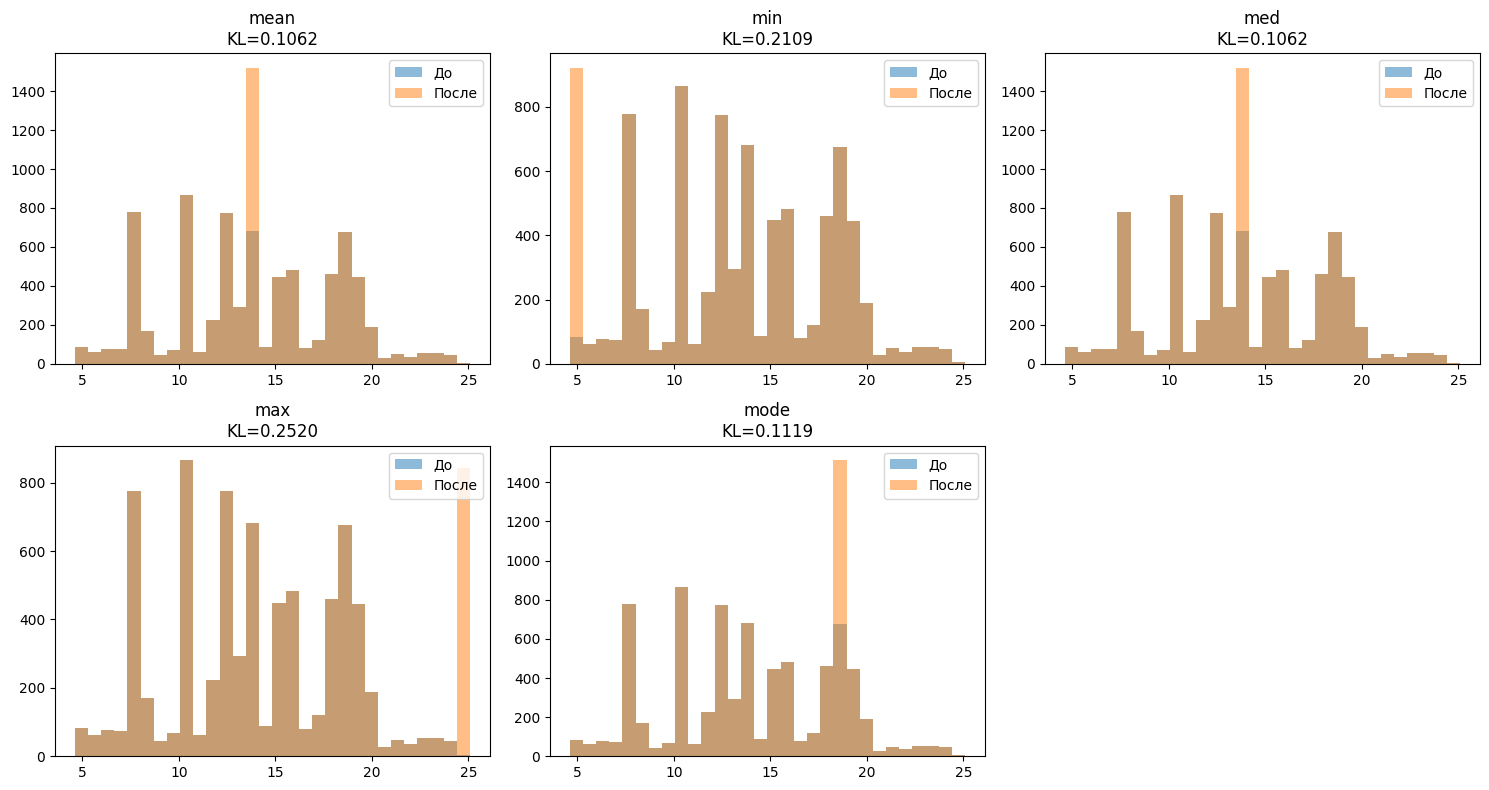

Статистические методы KL:
mean: 0.106189
min: 0.210852
med: 0.106189
max: 0.252025
mode: 0.111862


In [104]:
original = nan_col.dropna()

methods_stat = {
    'mean': nan_col.mean(),
    'min': nan_col.min(),
    'med': nan_col.median(),
    'max': nan_col.max(),
    'mode': nan_col.mode()[0]
}

kl_stat = {}

plt.figure(figsize=(15, 8))
for i, (name, value) in enumerate(methods_stat.items(), 1):
    filled = nan_col.fillna(value)
    kl = simple_kl(original, filled)
    kl_stat[name] = kl
    
    plt.subplot(2, 3, i)
    plt.hist(original, bins=30, alpha=0.5, label='До')
    plt.hist(filled, bins=30, alpha=0.5, label='После')
    plt.title(f'{name}\nKL={kl:.4f}')
    plt.legend()

plt.tight_layout()
plt.show()

print("Статистические методы KL:")
for name, kl in kl_stat.items():
    print(f"{name}: {kl:.6f}")

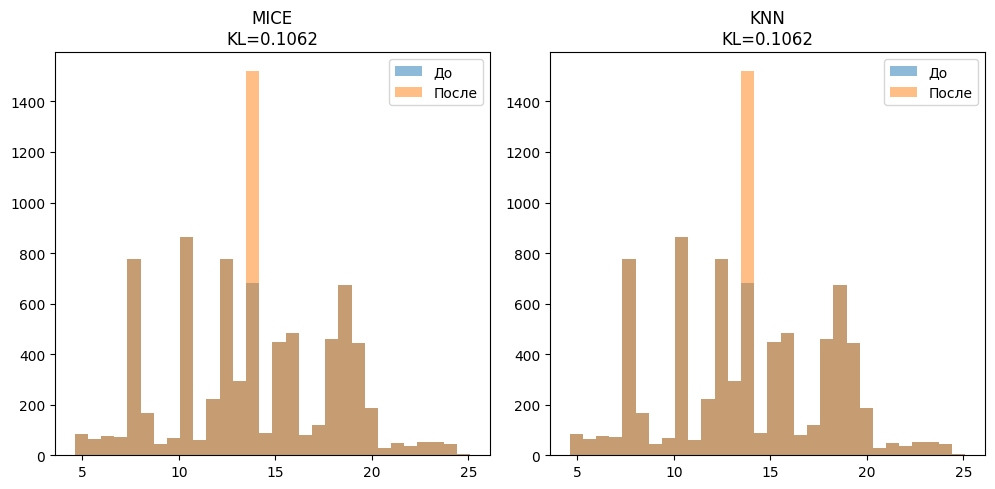

ML методы KL:
MICE: 0.106189
KNN: 0.106189


In [105]:
X = nan_col.values.reshape(-1, 1)

methods_ml = {
    'MICE': IterativeImputer(random_state=RANDOM_STATE),
    'KNN': KNNImputer(n_neighbors=7)
}

kl_ml = {}

plt.figure(figsize=(15, 5))
for i, (name, imp) in enumerate(methods_ml.items(), 1):
    filled_2d = imp.fit_transform(X)
    filled = filled_2d.flatten()
    kl = simple_kl(original, filled)
    kl_ml[name] = kl
    
    plt.subplot(1, 3, i)
    plt.hist(original, bins=30, alpha=0.5, label='До')
    plt.hist(filled, bins=30, alpha=0.5, label='После')
    plt.title(f'{name}\nKL={kl:.4f}')
    plt.legend()

plt.tight_layout()
plt.show()

print("ML методы KL:")
for name, kl in kl_ml.items():
    print(f"{name}: {kl:.6f}")

In [106]:
all_methods = {**kl_stat, **kl_ml}

print("Все методы:")
for name, kl in sorted(all_methods.items(), key=lambda x: x[1]):
    print(f"{name}: {kl:.6f}")

Все методы:
mean: 0.106189
med: 0.106189
MICE: 0.106189
KNN: 0.106189
mode: 0.111862
min: 0.210852
max: 0.252025


In [107]:
X_train['Магическая производительность'].fillna(methods_stat['mean'], inplace=True)
X_train

,Ритм магического ядра,Поток Энергий,Пламя Стихий,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Общая сила потоков,Общая сила ядра,Общее давление,Магическая производительность,Эффективность ядра,Магическая мощность
0,241.572139,8790.141,772.240,34.254,0.678,0.991,2,30253.638,7.189575e+06,15.862,13.657699,1.060409e+07,389.740761
1,141.591057,6838.435,517.051,16.754,0.156,0.959,0,3199.818,4.463545e+05,7.672,19.786154,2.861247e+06,-262.045170
2,201.516623,8471.841,682.640,23.849,0.472,0.998,2,21975.975,4.357902e+06,13.074,16.348729,9.232842e+06,-329.280718
3,323.317950,9305.741,901.076,58.585,1.160,0.989,3,51869.042,1.648698e+07,21.858,10.643586,1.421291e+07,4185.548201
4,141.564982,6642.099,468.577,8.163,0.093,0.973,0,763.532,1.059308e+05,7.144,13.821563,1.139041e+06,-177.673702
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8348,323.300567,9292.800,915.018,60.083,1.189,0.998,3,51865.526,1.648499e+07,22.300,10.383987,1.386458e+07,4746.608565
8349,323.319312,9306.729,933.160,61.190,1.211,0.972,3,51869.728,1.648724e+07,22.210,10.195343,1.361457e+07,5302.876480
8350,372.841179,9751.200,1089.292,90.760,1.797,0.973,3,74049.430,2.712781e+07,27.487,13.821563,1.509616e+07,17450.554156
8351,241.615179,8842.649,779.989,34.453,0.682,0.953,2,30289.777,7.199420e+06,15.626,13.577595,1.055633e+07,468.787782


In [108]:
X_test['Магическая производительность'].fillna(X_test['Магическая производительность'].mean(), inplace=True)
X_test

C:\Users\izgor\AppData\Local\Temp\ipykernel_16252\342079072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['Магическая производительность'].fillna(X_test['Магическая производительность'].mean(), inplace=True)


,Ритм магического ядра,Поток Энергий,Пламя Стихий,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Общая сила потоков,Общая сила ядра,Общее давление,Магическая производительность,Эффективность ядра,Магическая мощность
0,145.218550,7045.840,576.879,11.961,0.237,0.993,1,8495.786,1.216229e+06,8.898,19.535696,5.131769e+06,-335.558502
1,372.838875,9728.709,1064.615,88.928,1.760,0.994,3,74046.592,2.712664e+07,27.595,13.754539,1.541286e+07,15959.910428
2,280.441913,9117.010,821.362,43.923,0.870,0.989,3,39670.309,1.093881e+07,18.673,12.417517,1.257335e+07,1386.749225
3,280.447463,9138.462,840.619,44.791,0.887,0.951,3,39641.770,1.093116e+07,18.416,12.179526,1.232374e+07,1708.950528
4,241.630258,8824.273,774.265,34.208,0.677,0.968,2,30284.557,7.198684e+06,15.688,13.677873,1.063321e+07,406.403994
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3576,162.049318,7750.305,626.224,16.547,0.328,0.987,1,14947.605,2.385384e+06,10.514,18.820976,7.272513e+06,-378.572635
3577,201.514110,8494.519,725.337,26.049,0.516,0.954,2,21986.524,4.359941e+06,13.236,14.954651,8.449498e+06,-72.825901
3578,201.516309,8489.766,699.358,24.682,0.489,0.974,2,21982.656,4.359227e+06,13.086,15.780368,8.914575e+06,-234.474137
3579,145.219702,7091.791,569.364,11.629,0.230,0.987,1,8497.935,1.216543e+06,8.800,13.754539,5.289319e+06,-337.271264


# Дополнительное задание

$\text{NRMSE} = \frac{\text{RMSE}}{y_{\max} - y_{\min}}$

In [109]:
def nrmse(original, imputed, mask):
    rmse = np.sqrt(np.mean((original[mask] - imputed[mask])**2))
    nrmse = rmse / (original.max() - original.min())
    return nrmse

In [110]:
clean_data = nan_col.dropna().reset_index(drop=True)

indices = np.random.choice(len(clean_data), size=int(len(clean_data)*0.2), replace=False)
mask = np.zeros(len(clean_data), dtype=bool)
mask[indices] = True

corrupted_data = clean_data.copy()
corrupted_data[mask] = np.nan

print(f"Всего точек: {len(clean_data)}")
print(f"Пропусков создано: {mask.sum()}")

Всего точек: 8353
Пропусков создано: 1670


In [112]:
X_corrupted = corrupted_data.values.reshape(-1, 1)

methods = {
    'Mean': 'mean',
    'MICE': IterativeImputer(random_state=42),
    'KNN': KNNImputer(n_neighbors=10)
}

nrmse_results = {}

for name, method in methods.items():
    if name == 'Mean':
        fill_value = corrupted_data.mean()
        imputed_data = corrupted_data.fillna(fill_value)
    else:
        imputed_2d = method.fit_transform(X_corrupted)
        imputed_data = pd.Series(imputed_2d.flatten())

    res = nrmse(clean_data, imputed_data, mask)
    nrmse_results[name] = res
    
    print(f"{name}: NRMSE = {res:.6f}")

best_method = min(nrmse_results, key=nrmse_results.get)
print(f"Лучший метод: {best_method} (NRMSE = {nrmse_results[best_method]:.6f})")

Mean: NRMSE = 0.191626
MICE: NRMSE = 0.191626
KNN: NRMSE = 0.191626
Лучший метод: Mean (NRMSE = 0.191626)
